<a href="https://colab.research.google.com/github/pmusachio/loan-approval-eda/blob/main/notebooks/MVP_Analise_Loan_Approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Approval | Analise Exploratoria e Pre-Processamento

---

**Nome:** PAULO MUSACHIO </br>

**Matricula:** 4052024001876 </br>

**Dataset:** [Loan Approval Classification](https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data?select=loan_data.csv)


## Objetivo e Escopo
---

O objetivo e identificar quais variaveis do solicitante e do emprestimo estao mais associadas ao `loan_status`, encerrando a entrega na analise exploratoria e no pre-processamento.


### Hipóteses a Validar

1. `loan_percent_income`, `loan_int_rate` e `previous_loan_defaults_on_file` sao os principais sinais do `loan_status`
2. `person_home_ownership` e `loan_intent` diferenciam as taxas de aprovacao
3. A base contem outliers relevantes, mesmo sem valores nulos


### Tipo de Problema

Problema de **classificação binária**: o objetivo é prever o `loan_status` — **1 para aprovado** e **0 para rejeitado** — a partir de características do solicitante e do empréstimo.


### Sobre o Dataset

Base sintética de aprovação de empréstimos com informações de perfil pessoal, situação financeira e histórico de crédito. Disponível no [Kaggle](https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data?select=loan_data.csv).


### Atributos

| Atributo | Descrição |
|---|---|
| `person_age` | idade do solicitante |
| `person_gender` | gênero informado |
| `person_education` | nível de escolaridade |
| `person_income` | renda anual do solicitante |
| `person_emp_exp` | tempo de experiência profissional |
| `person_home_ownership` | situação de moradia |
| `loan_amnt` | valor solicitado no empréstimo |
| `loan_intent` | finalidade do empréstimo |
| `loan_int_rate` | taxa de juros do empréstimo |
| `loan_percent_income` | parcela da renda comprometida pelo empréstimo |
| `cb_person_cred_hist_length` | tempo de histórico de crédito |
| `credit_score` | score de crédito |
| `previous_loan_defaults_on_file` | indicador de defaults anteriores registrados |
| `loan_status` | alvo da análise: 1 = aprovado, 0 = rejeitado |


## Setup
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

### Constantes e Configurações

In [2]:
DATA_URL = 'https://raw.githubusercontent.com/pmusachio/loan-approval-eda/refs/heads/main/data/loan_data.csv'
RANDOM_STATE = 42
STATUS_LABELS = {0: 'Rejeitado', 1: 'Aprovado'}
STATUS_ORDER = ['Rejeitado', 'Aprovado']
NUMERICAL_COLUMNS = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'credit_score',
]
CATEGORICAL_COLUMNS = [
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file',
]
TARGET_COLUMN = 'loan_status'
TARGET_LABEL_COLUMN = 'loan_status_label'

df = pd.read_csv(DATA_URL)
df[TARGET_LABEL_COLUMN] = df[TARGET_COLUMN].map(STATUS_LABELS)


### Funções Auxiliares

In [3]:
def annotate_bar_values(ax, percent=False):
    for patch in ax.patches:
        height = patch.get_height()
        if percent:
            label = f'{height:.1f}%'
        else:
            label = f'{int(height):,}'.replace(',', '.')
        ax.annotate(
            label,
            (patch.get_x() + patch.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=10,
        )


def build_column_overview(frame, extra_excluded=None):
    excluded = set(extra_excluded or [])
    columns_to_describe = [col for col in frame.columns if col not in excluded]
    return pd.DataFrame({
        'tipo': frame[columns_to_describe].dtypes.astype(str),
        'nulos': frame[columns_to_describe].isna().sum(),
        'unicos': frame[columns_to_describe].nunique(),
    })


def build_numeric_summary(frame, columns):
    return pd.DataFrame({
        'minimo': frame[columns].min(),
        'maximo': frame[columns].max(),
        'mediana': frame[columns].median(),
        'moda': frame[columns].mode().iloc[0],
        'media': frame[columns].mean(),
        'desvio_padrao': frame[columns].std(),
        'ausentes': frame[columns].isna().sum(),
    }).round(2)


def plot_horizontal_bar(series, title, xlabel, color):
    ax = series.sort_values().plot(kind='barh', color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Variável')
    plt.show()


def plot_numeric_grid(frame, columns, n_rows, n_cols, log_scale_columns=None):
    log_scale_columns = set(log_scale_columns or [])
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 16))
    axes = np.array(axes).flatten()

    for ax, column in zip(axes, columns):
        sns.histplot(frame[column], bins=30, kde=True, ax=ax, color='#2b6cb0')
        ax.set_title(f'Distribuição de {column}')
        if column in log_scale_columns:
            ax.set_xscale('log')
            ax.set_xlabel(f'{column} (escala log)')

    for ax in axes[len(columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_categorical_grid(frame, columns, n_rows, n_cols):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
    axes = np.array(axes).flatten()

    for ax, column in zip(axes, columns):
        order = frame[column].value_counts().index
        sns.countplot(data=frame, y=column, order=order, ax=ax, color='#1f4e79')
        ax.set_title(f'Distribuição de {column}')
        ax.set_xlabel('Contagem')
        ax.set_ylabel(column)

    for ax in axes[len(columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_boxplot_by_status(frame, y_column, title, ylabel):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=frame, x=TARGET_LABEL_COLUMN, y=y_column, order=STATUS_ORDER)
    plt.title(title)
    plt.xlabel('Status')
    plt.ylabel(ylabel)
    plt.show()


In [4]:
df.sample(5)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,loan_status_label
19189,35.0,female,Master,13767.0,16,RENT,2500.0,EDUCATION,14.84,0.18,5.0,669,No,1,Aprovado
18790,30.0,male,Associate,83868.0,7,RENT,1000.0,HOMEIMPROVEMENT,8.59,0.01,5.0,545,No,1,Aprovado
17037,24.0,male,Associate,59943.0,0,RENT,7000.0,EDUCATION,7.49,0.12,4.0,663,No,1,Aprovado
1791,22.0,male,Bachelor,29269.0,0,RENT,2000.0,HOMEIMPROVEMENT,11.89,0.07,4.0,651,No,1,Aprovado
15889,26.0,female,Bachelor,15289.0,4,OWN,2500.0,EDUCATION,9.99,0.16,3.0,662,No,1,Aprovado


A base combina variaveis numericas e categoricas, alvo binario e ausencia aparente de nulos; isso reforca a necessidade de encoding e de tratamento de escala.


## Perfil do Dataset
---

In [5]:
print(f'linhas: {df.shape[0]:,}'.replace(',', '.'))
print(f'colunas: {len(NUMERICAL_COLUMNS) + len(CATEGORICAL_COLUMNS) + 1}')

column_overview = build_column_overview(df, extra_excluded=[TARGET_LABEL_COLUMN])
display(column_overview)


linhas: 45.000
colunas: 14


,tipo,nulos,unicos
person_age,float64,0,60
person_gender,object,0,2
person_education,object,0,5
person_income,float64,0,33989
person_emp_exp,int64,0,63
person_home_ownership,object,0,4
loan_amnt,float64,0,4483
loan_intent,object,0,6
loan_int_rate,float64,0,1302
loan_percent_income,float64,0,64


,contagem,percentual (%)
loan_status,,
Rejeitado,35000,77.78
Aprovado,10000,22.22


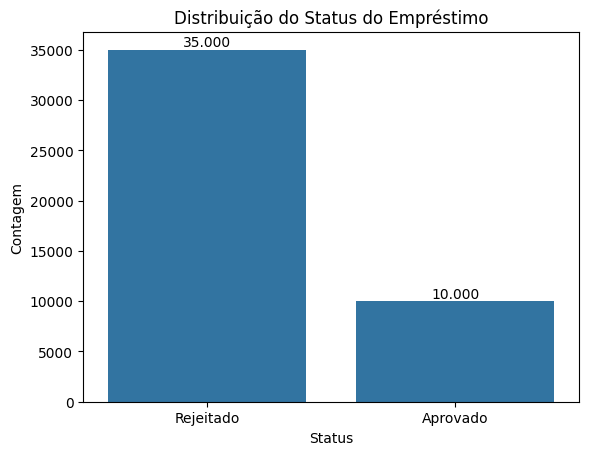

In [6]:
class_summary = pd.concat([
    df[TARGET_COLUMN].value_counts().sort_index().rename('contagem'),
    df[TARGET_COLUMN].value_counts(normalize=True).sort_index().mul(100).round(2).rename('percentual (%)')
], axis=1)
class_summary.index = class_summary.index.map(STATUS_LABELS)

display(class_summary)

ax = sns.countplot(data=df, x=TARGET_LABEL_COLUMN, order=STATUS_ORDER)
plt.title('Distribuição do Status do Empréstimo')
plt.xlabel('Status')
plt.ylabel('Contagem')
annotate_bar_values(ax)
plt.show()


Base desbalanceada: ~77,8% rejeitados e ~22,2% aprovados.


## Análise Univariada
---

In [7]:
df[NUMERICAL_COLUMNS].describe().T


,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00


In [8]:
summary_stats = build_numeric_summary(df, NUMERICAL_COLUMNS)
display(summary_stats)


,minimo,maximo,mediana,moda,media,desvio_padrao,ausentes
person_age,20.00,144.00,26.00,23.00,27.76,6.05,0
person_income,8000.00,7200766.00,67048.00,8000.00,80319.05,80422.50,0
person_emp_exp,0.00,125.00,4.00,0.00,5.41,6.06,0
loan_amnt,500.00,35000.00,8000.00,10000.00,9583.16,6314.89,0
loan_int_rate,5.42,20.00,11.01,11.01,11.01,2.98,0
loan_percent_income,0.00,0.66,0.12,0.08,0.14,0.09,0
cb_person_cred_hist_length,2.00,30.00,4.00,4.00,5.87,3.88,0
credit_score,390.00,850.00,640.00,658.00,632.61,50.44,0


Sem ausentes nas numericas. Ha outliers claros em `person_income`, `person_age` e `person_emp_exp`.


### Variáveis Numéricas

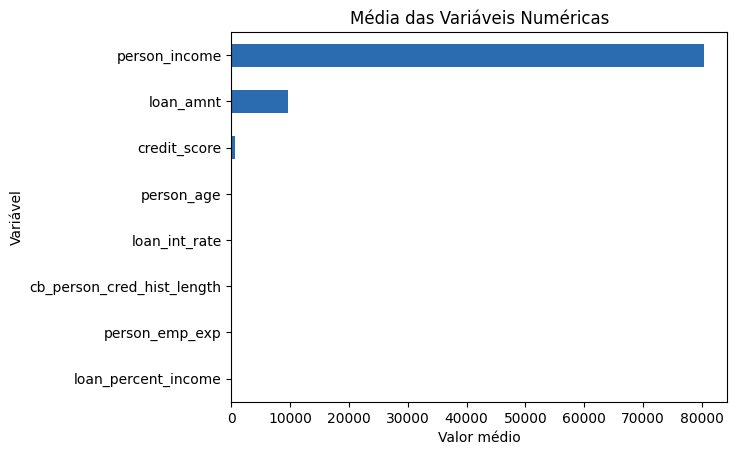

In [9]:
mean_series = df[NUMERICAL_COLUMNS].mean()
plot_horizontal_bar(mean_series, 'Média das Variáveis Numéricas', 'Valor médio', '#2b6cb0')


As escalas variam bastante entre as features, o que justifica o escalonamento posterior.


**Desvio padrão por variável:**

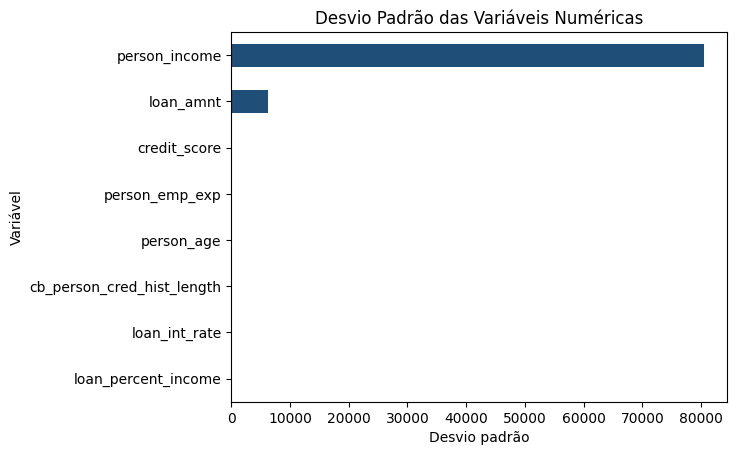

In [10]:
std_series = df[NUMERICAL_COLUMNS].std()
plot_horizontal_bar(std_series, 'Desvio Padrão das Variáveis Numéricas', 'Desvio padrão', '#1f4e79')


`person_income` e `loan_amnt` concentram a maior dispersao.


### Distribuições

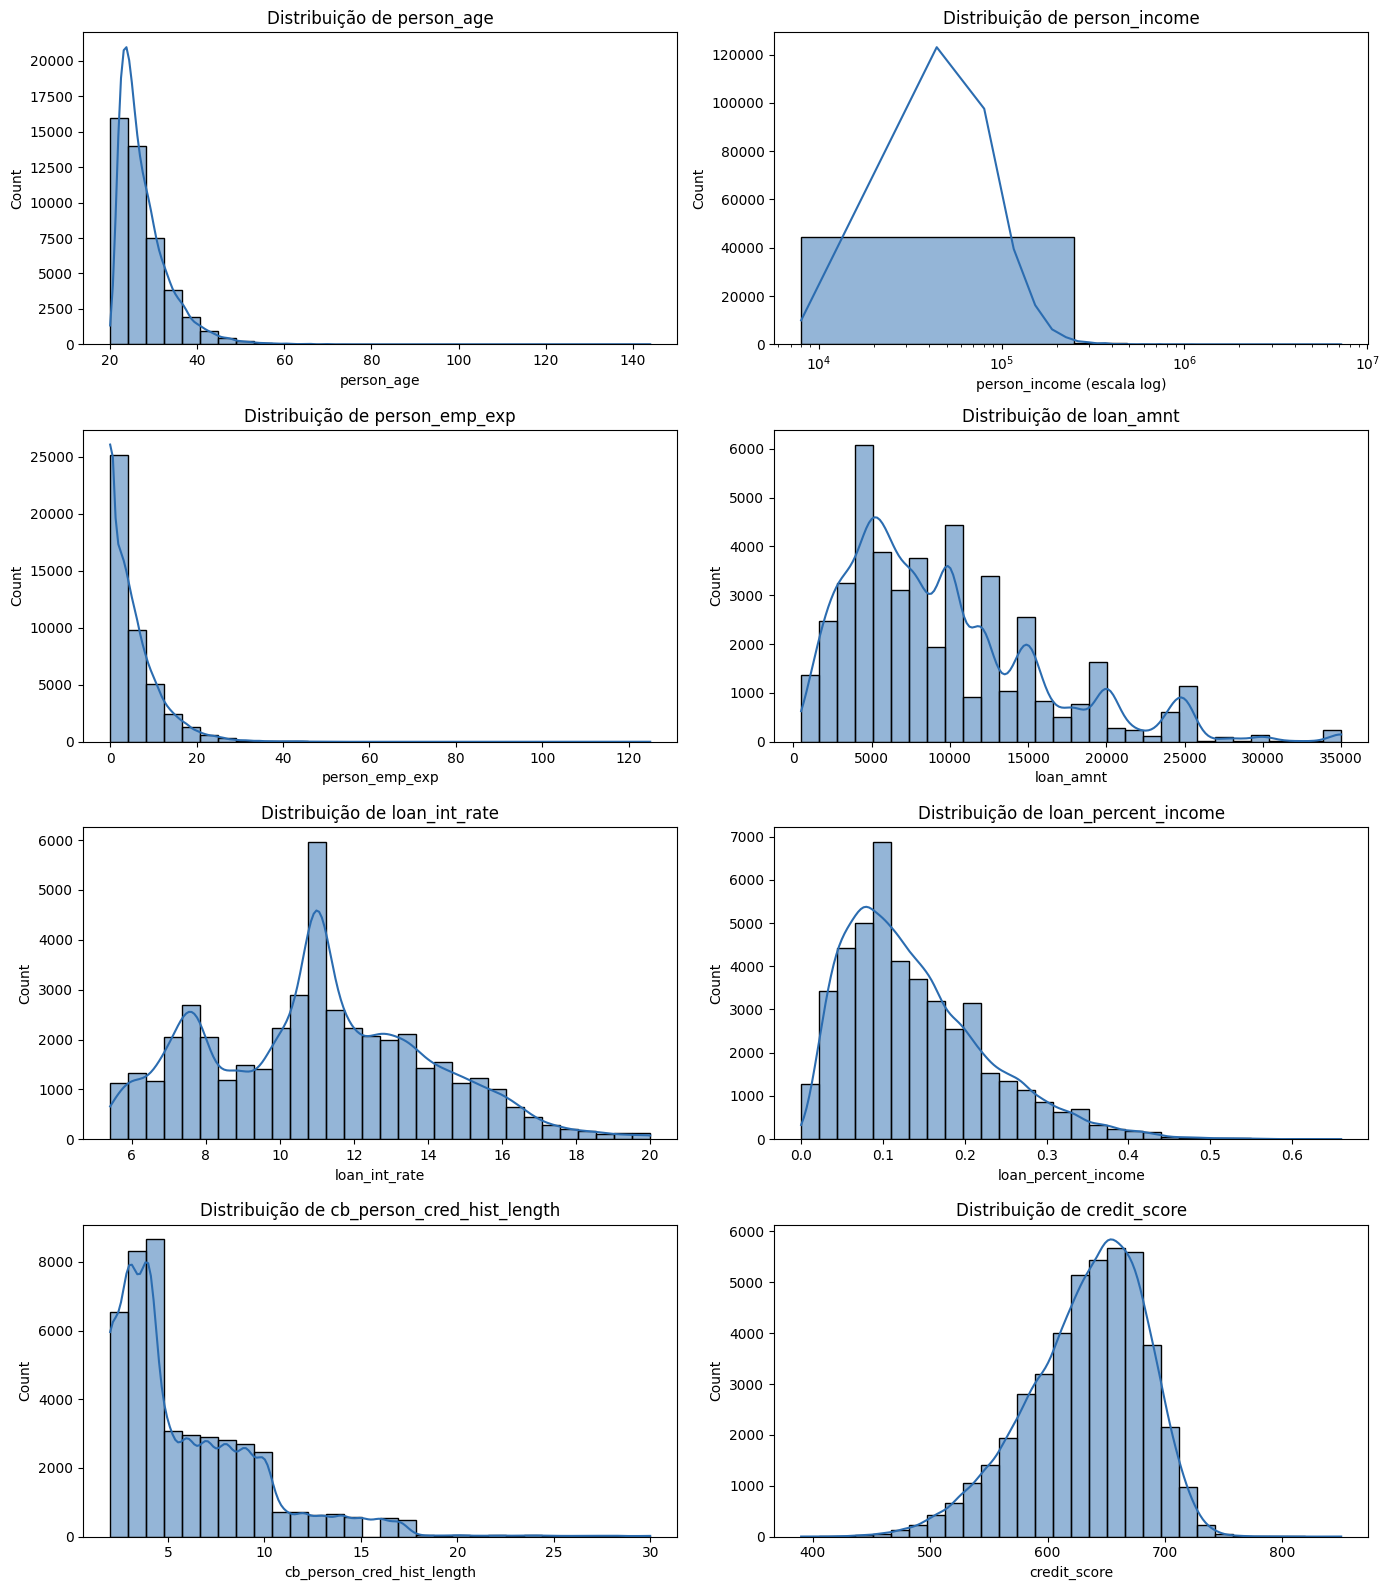

In [11]:
plot_numeric_grid(df, NUMERICAL_COLUMNS, n_rows=4, n_cols=2, log_scale_columns={'person_income'})


As distribuicoes sao assimetricas, com concentracao em faixas baixas e caudas longas.


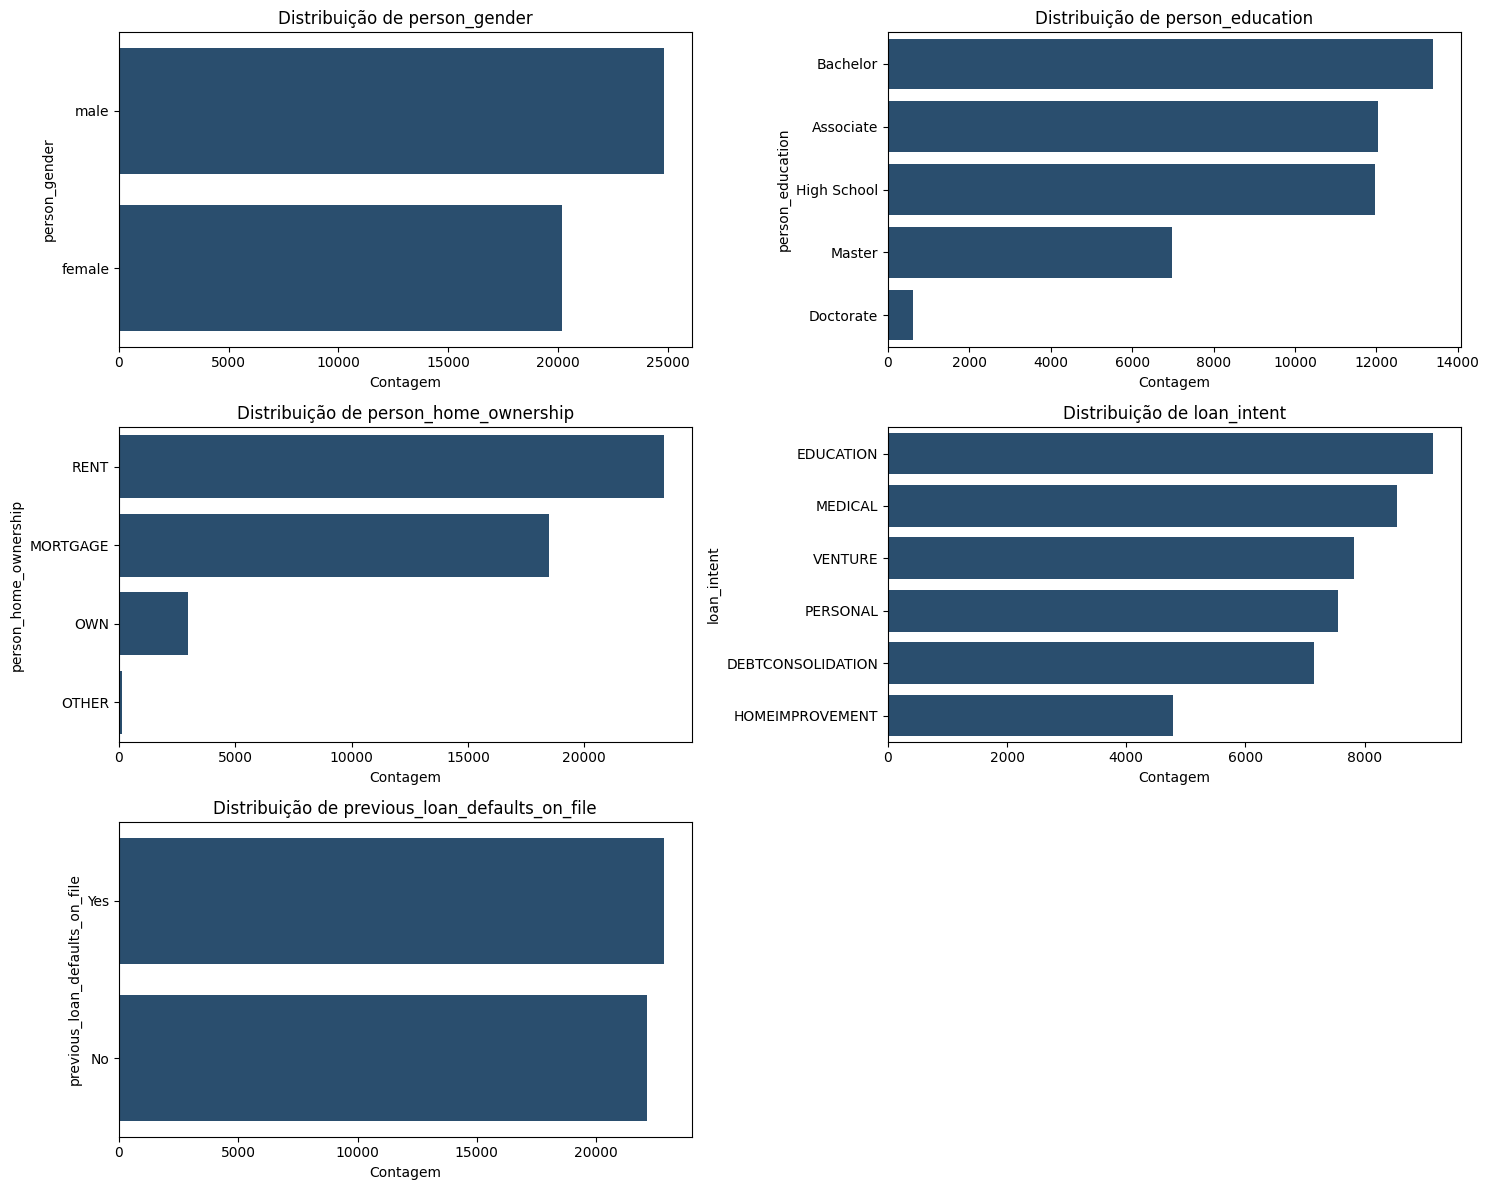

In [12]:
plot_categorical_grid(df, CATEGORICAL_COLUMNS, n_rows=3, n_cols=2)


As categorias sao desiguais em frequencia, especialmente em `person_home_ownership` e `loan_intent`.


### Análise de Cauda: Variáveis com Distribuição Assimétrica
- analise das caudas em detalhe para entender a concentração dos valores

#### `person_income`


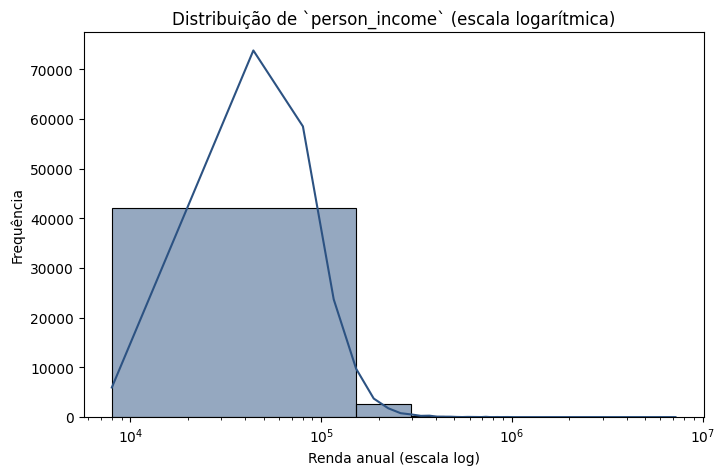

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df['person_income'], bins=50, kde=True, color='#2c5282')
plt.xscale('log')
plt.title('Distribuição de `person_income` (escala logarítmica)')
plt.xlabel('Renda anual (escala log)')
plt.ylabel('Frequência')
plt.show()


`person_income` e fortemente assimetrica a direita, com poucos valores muito altos puxando a media.


#### `loan_percent_income`


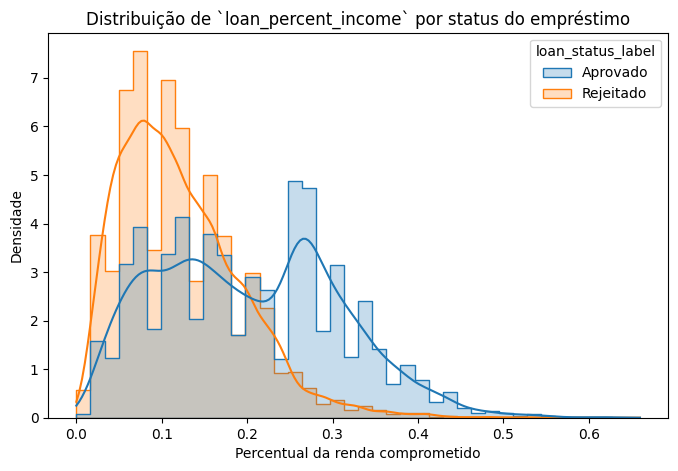

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x='loan_percent_income',
    hue=TARGET_LABEL_COLUMN,
    bins=40,
    kde=True,
    stat='density',
    common_norm=False,
    element='step'
)
plt.title('Distribuição de `loan_percent_income` por status do empréstimo')
plt.xlabel('Percentual da renda comprometido')
plt.ylabel('Densidade')
plt.show()


`loan_percent_income` mostra associacao visual forte com o alvo nesta base.


## Análise Bivariada: Relação com o Target
---

In [15]:
comparison_columns = ['person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']
df.groupby(TARGET_LABEL_COLUMN)[comparison_columns].agg(['mean', 'median']).round(2)


person_income          loan_amnt         loan_int_rate  \
                           mean   median      mean  median          mean   
loan_status_label                                                          
Aprovado               59886.10  50629.0  10855.69  9750.0         12.86   
Rejeitado              86157.04  72928.0   9219.58  8000.0         10.48   

                         loan_percent_income         
                  median                mean median  
loan_status_label                                    
Aprovado           12.98                0.20   0.20  
Rejeitado          10.85                0.12   0.11

### Variáveis Numéricas vs. loan_status

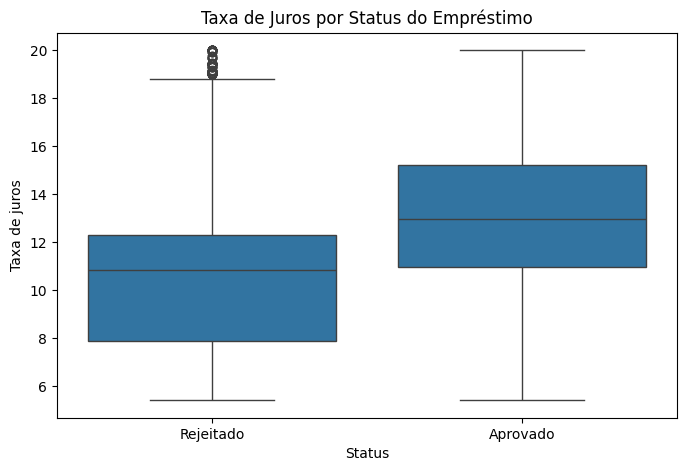

In [16]:
plot_boxplot_by_status(df, 'loan_int_rate', 'Taxa de Juros por Status do Empréstimo', 'Taxa de juros')


`loan_int_rate` separa os grupos e aparece mais alta entre aprovados.


**`loan_percent_income` por status do empréstimo**

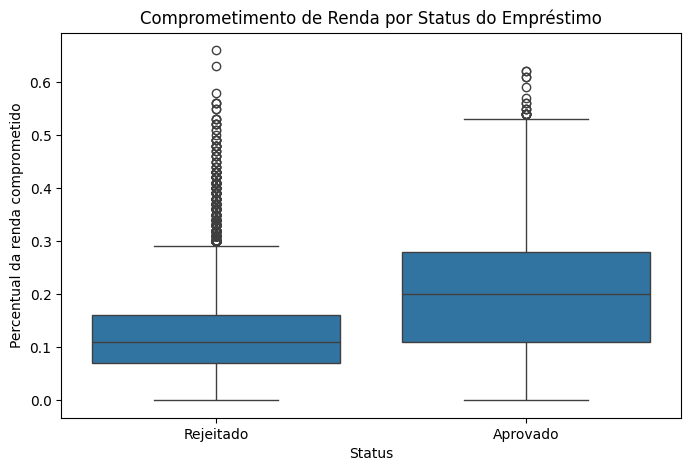

In [17]:
plot_boxplot_by_status(df, 'loan_percent_income', 'Comprometimento de Renda por Status do Empréstimo', 'Percentual da renda comprometido')


`loan_percent_income` e a variavel numerica que melhor separa aprovados e rejeitados.


### Correlações entre Variáveis


In [18]:
corr_matrix = df[NUMERICAL_COLUMNS + [TARGET_COLUMN]].corr(numeric_only=True)
corr_with_target = corr_matrix[TARGET_COLUMN].sort_values(ascending=False)

corr_with_target


,loan_status
loan_status,1.000000
loan_percent_income,0.384880
loan_int_rate,0.332005
loan_amnt,0.107714
credit_score,-0.007647
cb_person_cred_hist_length,-0.014851
person_emp_exp,-0.020481
person_age,-0.021476
person_income,-0.135808


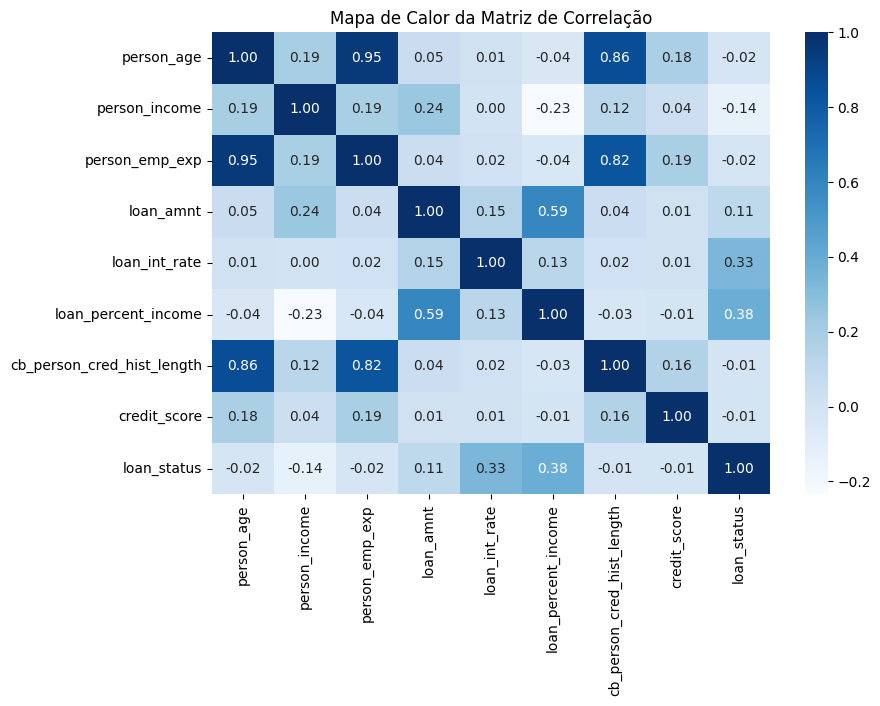

In [19]:
plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Mapa de Calor da Matriz de Correlação')
plt.show()


`loan_percent_income` e `loan_int_rate` tem as correlacoes lineares mais fortes com o alvo; `person_income` aparece com relacao negativa.


### Variáveis Categóricas vs. loan_status

,total,taxa_aprovacao,taxa_aprovacao_pct
commitment_band,,,
Até 10%,18866,0.117884,11.79
10% a 20%,16926,0.175647,17.56
20% a 30%,6808,0.447855,44.79
Acima de 30%,2400,0.730833,73.08


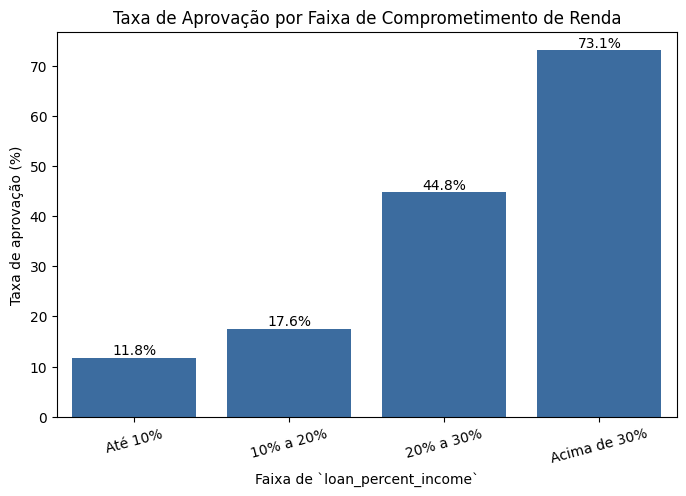

In [20]:
df['commitment_band'] = pd.cut(
    df['loan_percent_income'],
    bins=[0, 0.10, 0.20, 0.30, 1.0],
    labels=['Até 10%', '10% a 20%', '20% a 30%', 'Acima de 30%'],
    include_lowest=True,
)

approval_by_commitment = (
    df.groupby('commitment_band', observed=False)[TARGET_COLUMN]
      .agg(total='count', taxa_aprovacao='mean')
      .assign(taxa_aprovacao_pct=lambda frame: (frame['taxa_aprovacao'] * 100).round(2))
)

display(approval_by_commitment)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=approval_by_commitment.index,
    y=approval_by_commitment['taxa_aprovacao_pct'],
    color='#2b6cb0'
)
plt.title('Taxa de Aprovação por Faixa de Comprometimento de Renda')
plt.xlabel('Faixa de `loan_percent_income`')
plt.ylabel('Taxa de aprovação (%)')
plt.xticks(rotation=15)
annotate_bar_values(ax, percent=True)
plt.show()


Quanto maior `loan_percent_income`, maior a taxa de aprovacao nesta base sintetica.


,total,taxa_aprovacao,taxa_aprovacao_pct
person_home_ownership,,,
OTHER,117,0.333333,33.33
RENT,23443,0.323977,32.40
MORTGAGE,18489,0.115961,11.60
OWN,2951,0.075229,7.52


,total,taxa_aprovacao,taxa_aprovacao_pct
loan_intent,,,
DEBTCONSOLIDATION,7145,0.302729,30.27
MEDICAL,8548,0.278194,27.82
HOMEIMPROVEMENT,4783,0.263015,26.30
PERSONAL,7552,0.201404,20.14
EDUCATION,9153,0.169562,16.96
VENTURE,7819,0.144264,14.43


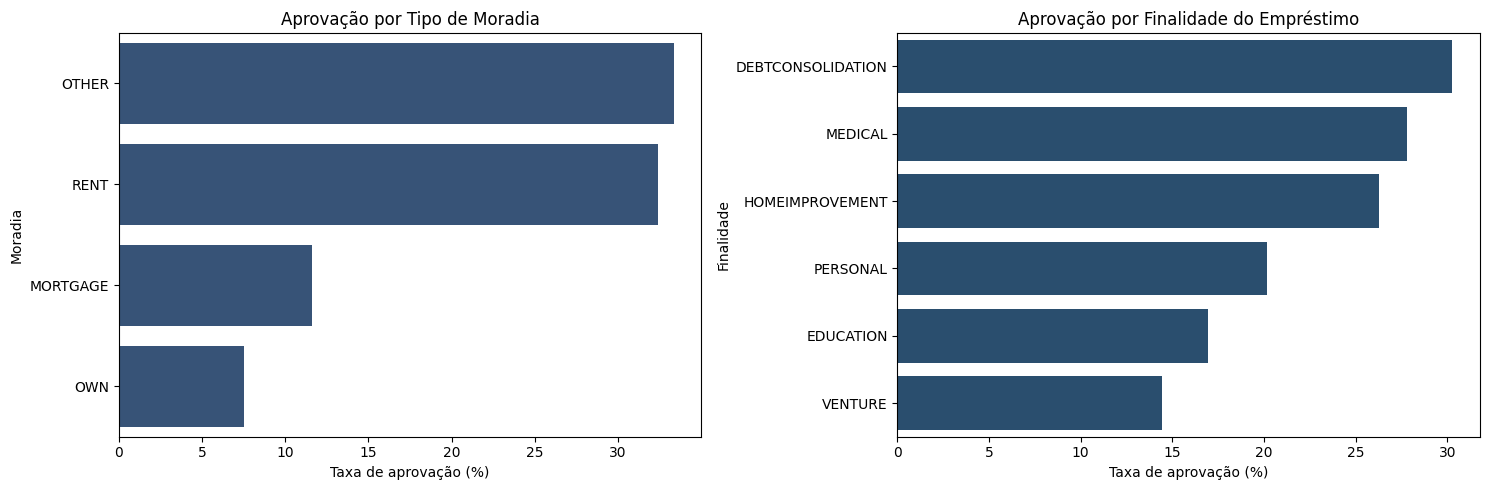

In [21]:
home_approval_plot = (
    df.groupby('person_home_ownership')[TARGET_COLUMN]
      .agg(total='count', taxa_aprovacao='mean')
      .assign(taxa_aprovacao_pct=lambda frame: (frame['taxa_aprovacao'] * 100).round(2))
      .sort_values('taxa_aprovacao_pct', ascending=False)
)

intent_approval_plot = (
    df.groupby('loan_intent')[TARGET_COLUMN]
      .agg(total='count', taxa_aprovacao='mean')
      .assign(taxa_aprovacao_pct=lambda frame: (frame['taxa_aprovacao'] * 100).round(2))
      .sort_values('taxa_aprovacao_pct', ascending=False)
)

display(home_approval_plot)
display(intent_approval_plot)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=home_approval_plot.reset_index(),
    x='taxa_aprovacao_pct',
    y='person_home_ownership',
    ax=axes[0],
    color='#2c5282'
)
axes[0].set_title('Aprovação por Tipo de Moradia')
axes[0].set_xlabel('Taxa de aprovação (%)')
axes[0].set_ylabel('Moradia')

sns.barplot(
    data=intent_approval_plot.reset_index(),
    x='taxa_aprovacao_pct',
    y='loan_intent',
    ax=axes[1],
    color='#1f4e79'
)
axes[1].set_title('Aprovação por Finalidade do Empréstimo')
axes[1].set_xlabel('Taxa de aprovação (%)')
axes[1].set_ylabel('Finalidade')

plt.tight_layout()
plt.show()


Moradia e finalidade ajudam a diferenciar perfis, mas com intensidade menor que o historico de defaults.


loan_status_label,Aprovado,Rejeitado
previous_loan_defaults_on_file,,
No,45.16,54.84
Yes,0.00,100.00


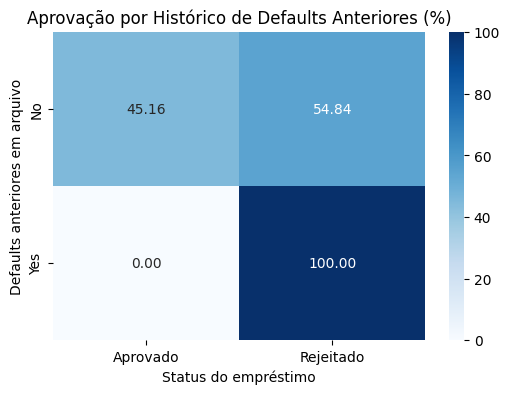

In [22]:
previous_defaults_heatmap = pd.crosstab(
    df['previous_loan_defaults_on_file'],
    df[TARGET_LABEL_COLUMN],
    normalize='index'
).mul(100).round(2)

display(previous_defaults_heatmap)

plt.figure(figsize=(6, 4))
sns.heatmap(previous_defaults_heatmap, annot=True, fmt='.2f', cmap='Blues')
plt.title('Aprovação por Histórico de Defaults Anteriores (%)')
plt.xlabel('Status do empréstimo')
plt.ylabel('Defaults anteriores em arquivo')
plt.show()


`previous_loan_defaults_on_file` e o separador mais forte da base.


## Qualidade e Consistência dos Dados
---

In [23]:
total_missing_values = int(df.drop(columns=[TARGET_LABEL_COLUMN]).isna().sum().sum())
quality_flags = pd.Series({
    'idade_maior_que_80': (df['person_age'] > 80).sum(),
    'idade_maior_que_100': (df['person_age'] > 100).sum(),
    'experiencia_maior_que_50': (df['person_emp_exp'] > 50).sum(),
    'renda_maior_que_1_milhao': (df['person_income'] > 1_000_000).sum(),
}, name='quantidade')

print(f'Total de valores nulos: {total_missing_values}')
display(quality_flags.to_frame())


Total de valores nulos: 0


,quantidade
idade_maior_que_80,9
idade_maior_que_100,7
experiencia_maior_que_50,12
renda_maior_que_1_milhao,24


Sem nulos; ha poucos extremos, mas suficientes para influenciar transformacoes de escala.


## Pré-Processamento
---

In [24]:
X = df.drop(columns=[TARGET_COLUMN, TARGET_LABEL_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

train_numeric_columns = X.select_dtypes(include='number').columns.tolist()
train_categorical_columns = X.select_dtypes(exclude='number').columns.tolist()


In [25]:
print(f'Dimensões de X_train: {X_train.shape}')
print(f'Dimensões de X_test: {X_test.shape}')
print(f'Dimensões de y_train: {y_train.shape}')
print(f'Dimensões de y_test: {y_test.shape}')
print()
print('Variáveis numéricas:', train_numeric_columns)
print()
print('Variáveis categóricas:', train_categorical_columns)


Dimensões de X_train: (36000, 14)
Dimensões de X_test: (9000, 14)
Dimensões de y_train: (36000,)
Dimensões de y_test: (9000,)

Variáveis numéricas: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

Variáveis categóricas: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file', 'commitment_band']


### Normalização (MinMaxScaler)


In [26]:
minmax_scaler = MinMaxScaler()

X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

X_train_norm[train_numeric_columns] = minmax_scaler.fit_transform(X_train[train_numeric_columns])
X_test_norm[train_numeric_columns] = minmax_scaler.transform(X_test[train_numeric_columns])

X_train_norm.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,commitment_band
6048,0.032258,male,Master,0.007079,0.016,OWN,0.113043,VENTURE,0.039095,0.106061,0.071429,0.578261,Yes,Até 10%
3346,0.024194,female,High School,0.005265,0.016,RENT,0.304348,VENTURE,0.383402,0.363636,0.000000,0.530435,Yes,20% a 30%
17998,0.072581,female,Master,0.032386,0.056,MORTGAGE,0.275362,VENTURE,0.498628,0.060606,0.250000,0.539130,Yes,Até 10%
24988,0.080645,female,Bachelor,0.012278,0.080,MORTGAGE,0.159420,MEDICAL,0.553498,0.090909,0.214286,0.634783,No,Até 10%
23231,0.072581,male,Bachelor,0.009041,0.056,MORTGAGE,0.217391,PERSONAL,0.349108,0.166667,0.214286,0.552174,Yes,10% a 20%


`MinMaxScaler` e aplicado apenas no treino. Neste conjunto, ele evidencia a sensibilidade a outliers.


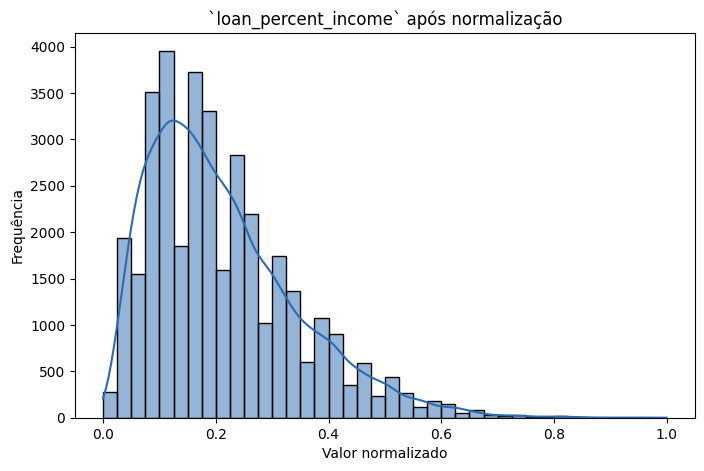

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(X_train_norm['loan_percent_income'], bins=40, kde=True, color='#2b6cb0')
plt.title('`loan_percent_income` após normalização')
plt.xlabel('Valor normalizado')
plt.ylabel('Frequência')
plt.show()


### Padronização (StandardScaler)


In [28]:
standard_scaler = StandardScaler()

X_train_std = X_train.copy()
X_test_std = X_test.copy()

X_train_std[train_numeric_columns] = standard_scaler.fit_transform(X_train[train_numeric_columns])
X_test_std[train_numeric_columns] = standard_scaler.transform(X_test[train_numeric_columns])

X_train_std.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,commitment_band
6048,-0.622502,male,Master,-0.256600,-0.561597,OWN,-0.823150,VENTURE,-1.687749,-0.800883,-0.480436,0.464300,Yes,Até 10%
3346,-0.787921,female,High School,-0.411269,-0.561597,RENT,0.224243,VENTURE,-0.001061,1.154322,-0.996078,0.026852,Yes,20% a 30%
17998,0.204591,female,Master,1.902342,0.262920,MORTGAGE,0.065547,VENTURE,0.563408,-1.145920,0.808671,0.106388,Yes,Até 10%
24988,0.370009,female,Bachelor,0.186994,0.757630,MORTGAGE,-0.569236,MEDICAL,0.832203,-0.915896,0.550850,0.981285,No,Até 10%
23231,0.204591,male,Bachelor,-0.089147,0.262920,MORTGAGE,-0.251845,PERSONAL,-0.169058,-0.340835,0.550850,0.225692,Yes,10% a 20%


A padronizacao fica mais estavel que o Min-Max neste conjunto, mas nao elimina o efeito dos outliers.


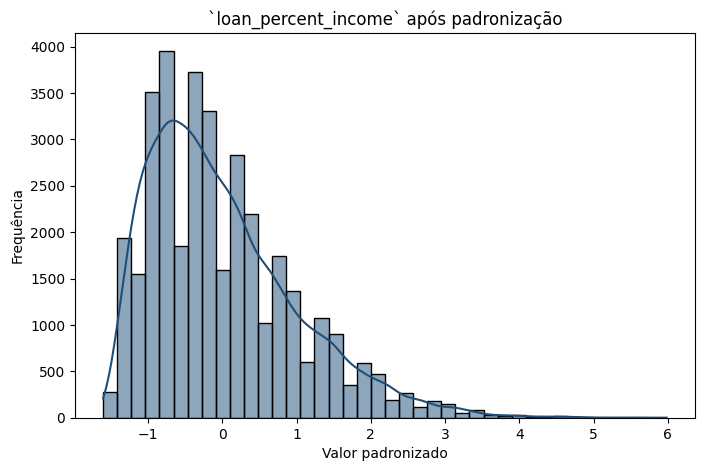

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(X_train_std['loan_percent_income'], bins=40, kde=True, color='#1f4e79')
plt.title('`loan_percent_income` após padronização')
plt.xlabel('Valor padronizado')
plt.ylabel('Frequência')
plt.show()


### Encoding e Estrutura Final da Base


In [30]:
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('scaler', StandardScaler())]), train_numeric_columns),
        ('cat', Pipeline([('encoder', ohe)]), train_categorical_columns),
    ]
)

X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print('Formato após pré-processamento:')
print('X_train_ready:', X_train_ready.shape)
print('X_test_ready:', X_test_ready.shape)

if hasattr(preprocessor, 'get_feature_names_out'):
    feature_names = preprocessor.get_feature_names_out()
    print()
    print('Primeiras features transformadas:')
    print(feature_names[:15])


Formato após pré-processamento:
X_train_ready: (36000, 31)
X_test_ready: (9000, 31)

Primeiras features transformadas:
['num__person_age' 'num__person_income' 'num__person_emp_exp'
 'num__loan_amnt' 'num__loan_int_rate' 'num__loan_percent_income'
 'num__cb_person_cred_hist_length' 'num__credit_score'
 'cat__person_gender_female' 'cat__person_gender_male'
 'cat__person_education_Associate' 'cat__person_education_Bachelor'
 'cat__person_education_Doctorate' 'cat__person_education_High School'
 'cat__person_education_Master']


Com o pre-processamento concluido, ficam registrados tres pontos:

- O alvo e desbalanceado e isso precisa acompanhar a interpretacao dos resultados
- `previous_loan_defaults_on_file` so e valida se estiver disponivel no momento da decisao
- `commitment_band` deriva de `loan_percent_income` e introduz redundancia explicita na base preparada


## Sintese dos Achados
---


### Sinais Numericos e Target


In [31]:
comparison_columns = ['person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']
resumo_hipotese_1 = df.groupby(TARGET_LABEL_COLUMN)[comparison_columns].mean().round(2)
resumo_hipotese_1


,person_income,loan_amnt,loan_int_rate,loan_percent_income
loan_status_label,,,,
Aprovado,59886.10,10855.69,12.86,0.20
Rejeitado,86157.04,9219.58,10.48,0.12


**Confirmada.** `loan_percent_income` e `loan_int_rate` sao os sinais numericos mais fortes do alvo. O padrao, porem, e contraintuitivo para credito real: aprovados tem juros mais altos, maior comprometimento de renda e renda menor. Aqui isso deve ser tratado como caracteristica da base sintetica.


### Variaveis Categoricas e Historico de Defaults


In [32]:
home_ownership_rate = (
    df.groupby('person_home_ownership')[TARGET_COLUMN]
      .agg(total='count', taxa_aprovacao='mean')
      .sort_values('taxa_aprovacao', ascending=False)
)

loan_intent_rate = (
    df.groupby('loan_intent')[TARGET_COLUMN]
      .agg(total='count', taxa_aprovacao='mean')
      .sort_values('taxa_aprovacao', ascending=False)
)

previous_defaults_rate = pd.crosstab(
    df['previous_loan_defaults_on_file'],
    df[TARGET_LABEL_COLUMN],
    normalize='index'
).round(3)

display(home_ownership_rate)
display(loan_intent_rate)
display(previous_defaults_rate)


,total,taxa_aprovacao
person_home_ownership,,
OTHER,117,0.333333
RENT,23443,0.323977
MORTGAGE,18489,0.115961
OWN,2951,0.075229


,total,taxa_aprovacao
loan_intent,,
DEBTCONSOLIDATION,7145,0.302729
MEDICAL,8548,0.278194
HOMEIMPROVEMENT,4783,0.263015
PERSONAL,7552,0.201404
EDUCATION,9153,0.169562
VENTURE,7819,0.144264


loan_status_label,Aprovado,Rejeitado
previous_loan_defaults_on_file,,
No,0.452,0.548
Yes,0.000,1.000


**Confirmada.** Moradia, finalidade e historico de defaults diferenciam as taxas de aprovacao. O principal destaque e `previous_loan_defaults_on_file`, com 0% de aprovacao quando `Yes`.


### Qualidade da Base e Outliers


In [33]:
extreme_values = {
    'idade_maxima': df['person_age'].max(),
    'experiencia_maxima': df['person_emp_exp'].max(),
    'renda_maxima': df['person_income'].max(),
    'qtd_idades_acima_100': int((df['person_age'] > 100).sum()),
    'qtd_rendas_acima_1_milhao': int((df['person_income'] > 1_000_000).sum()),
}

pd.Series(extreme_values)


,0
idade_maxima,144.0
experiencia_maxima,125.0
renda_maxima,7200766.0
qtd_idades_acima_100,7.0
qtd_rendas_acima_1_milhao,24.0


**Confirmada.** Nao ha nulos, mas ha extremos relevantes em idade, experiencia e renda. Eles sao poucos, porem suficientes para influenciar normalizacao e padronizacao.


## Conclusoes Finais
---

A entrega cumpre o objetivo de analisar a base e deixa-la preparada ate o pre-processamento. O dataset tem 45.000 registros, nao apresenta valores ausentes, e desbalanceado e concentra seus sinais mais fortes em `loan_percent_income`, `loan_int_rate` e `previous_loan_defaults_on_file`.

Como a base e sintetica, alguns padroes sao contraintuitivos para credito real. Por isso, os achados devem ser lidos como comportamento desta base, e nao como regra de negocio.

O notebook se encerra com divisao treino/teste estratificada, escalonamento documentado para variaveis numericas, encoding das categoricas e registro dos principais cuidados metodologicos: desbalanceamento, outliers e redundancia entre `loan_percent_income` e `commitment_band`.
